In [146]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2020-01-01", end="2025-10-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["log_change"] = np.log(returns["Close"] / returns["Close"].shift(1))

# 비율 변화량 계산 (pct_change 사용)
returns["change"] = returns["Close"].pct_change()

# change를 logchange로부터 복구
returns["test"] = np.exp(returns["log_change"]) - 1

# 불필요한 NaN 값 제거
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["Close", "change", "log_change", "test"]]

# 데이터 분할 기준일: 가장 최신 날짜 기준으로 일주일 전
split_date = returns.index[-30]

# 학습 데이터: 일주일 전까지
train_data = returns[returns.index < split_date]

# 검증 데이터: 일주일 동안
test_data = returns[returns.index >= split_date]

print(f"학습 데이터 기간: {train_data.index.min()} ~ {train_data.index.max()}")
print(f"검증 데이터 기간: {test_data.index.min()} ~ {test_data.index.max()}")

print(returns)
print(train_data)
print(test_data)

[*********************100%***********************]  1 of 1 completed

학습 데이터 기간: 2020-01-03 00:00:00 ~ 2025-03-27 00:00:00
검증 데이터 기간: 2025-03-28 00:00:00 ~ 2025-05-09 00:00:00
Price             Close    change  log_change      test
Date                                                   
2020-01-03  3234.850098 -0.007060   -0.007085 -0.007060
2020-01-06  3246.280029  0.003533    0.003527  0.003533
2020-01-07  3237.179932 -0.002803   -0.002807 -0.002803
2020-01-08  3253.050049  0.004902    0.004890  0.004902
2020-01-09  3274.699951  0.006655    0.006633  0.006655
...                 ...       ...         ...       ...
2025-05-05  5650.379883 -0.006382   -0.006402 -0.006382
2025-05-06  5606.910156 -0.007693   -0.007723 -0.007693
2025-05-07  5631.279785  0.004346    0.004337  0.004346
2025-05-08  5663.939941  0.005800    0.005783  0.005800
2025-05-09  5660.700195 -0.000572   -0.000572 -0.000572

[1345 rows x 4 columns]
Price             Close    change  log_change      test
Date                                                   
2020-01-03  3234.850098 -0.00

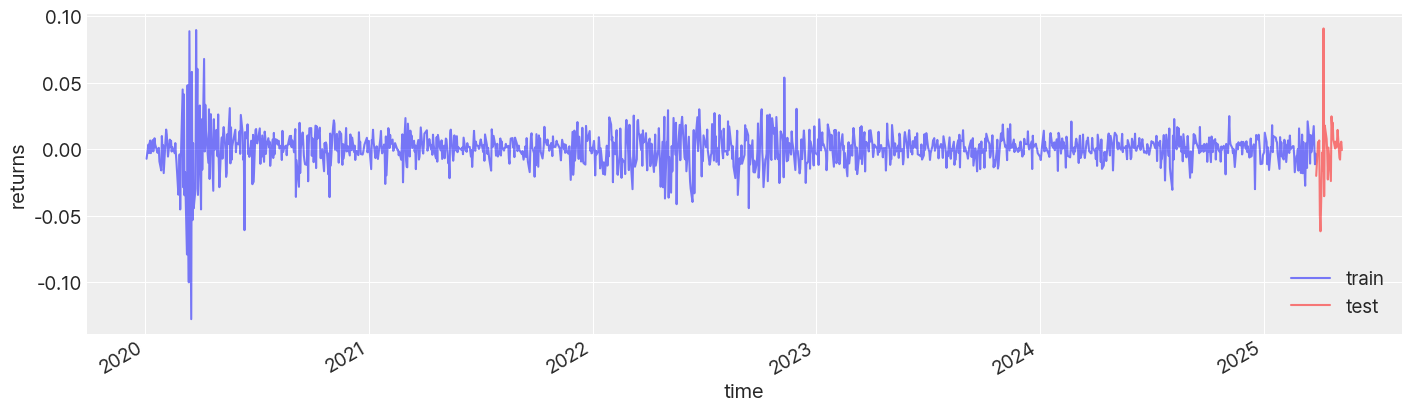

In [147]:
fig, ax = plt.subplots(figsize=(14, 4))
train_data.plot(y="log_change", label="train", ax=ax, color="blue", alpha=0.5)
test_data.plot(y="log_change", label="test", ax=ax, color="red", alpha=0.5)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [148]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=step_size, dims="time")
        volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility), dims="time")
        nu = pm.Exponential("nu", 0.1)

        # 포아송 분포로 점프 횟수 결정 (λ)
        # lambda_jump = pm.Exponential("lambda_jump", 1.0)
        # jump_counts = pm.Poisson("jump_counts", mu=0.0137*252, dims="time")

        # 각 시점에서 점프가 발생할 확률
        # jump_prob = pm.Beta("jump_prob", alpha=2, beta=10)
        jump_indicator = pm.Bernoulli("jump_indicator", p=0.0137, dims="time")

        # 점프 크기
        delta = pm.LogNormal("delta", mu=0, sigma=1)
        jump_size = pm.Normal("y", mu=-0.5 * delta**2, sigma=delta**2, dims="time")

        # 점프 효과
        jump_effect = pm.Deterministic("jump_effect", jump_indicator * np.exp(jump_size))

        # log_volatility_with_jump = log_volatility

        log_volatility_with_jump = np.log(volatility + jump_effect)
        # volatility_with_jump = pm.Deterministic("volatility_with_jump", pm.math.exp(log_volatility_with_jump))

        lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility_with_jump))
        sigma = pm.Deterministic("sigma", pm.math.exp(-log_volatility))

        # pm.StudentT(
        #     "returns", nu=nu, lam=lam, observed=data["log_change"], dims="time"
        # )

        pm.StudentT(
            "returns", nu=nu, sigma=sigma , observed=data["log_change"], dims="time"
        ) 
    return model


stochastic_vol_model = make_stochastic_volatility_model(train_data)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


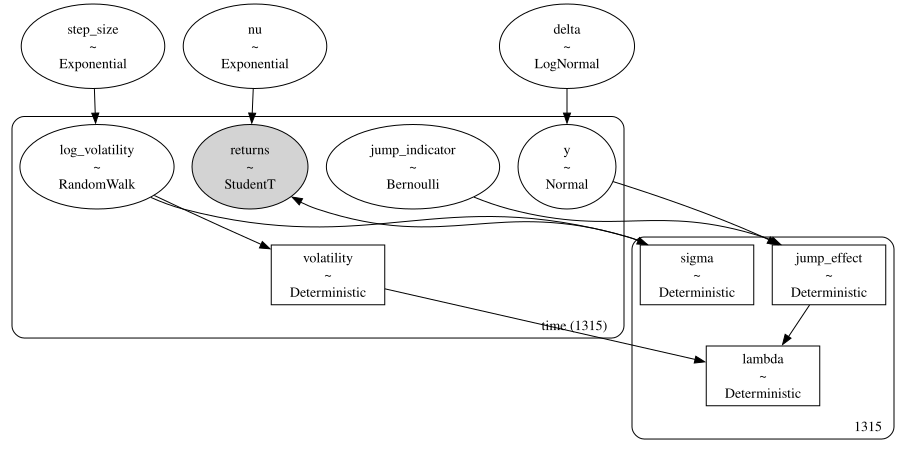

In [149]:
pm.model_to_graphviz(stochastic_vol_model)

In [150]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [151]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [delta, jump_indicator, log_volatility, nu, returns, step_size, y]


In [152]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [153]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 1315, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2020-01-03 2020-01-06 ... 2025-03-27
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 7.876e+40 ... 8.984e-115
Attributes:
    created_at:                 2025-05-09T14:52:59.744887
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [154]:
prior_predictive["returns"].shape

(1315, 500)

/tmp/ipykernel_83741/2910044826.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


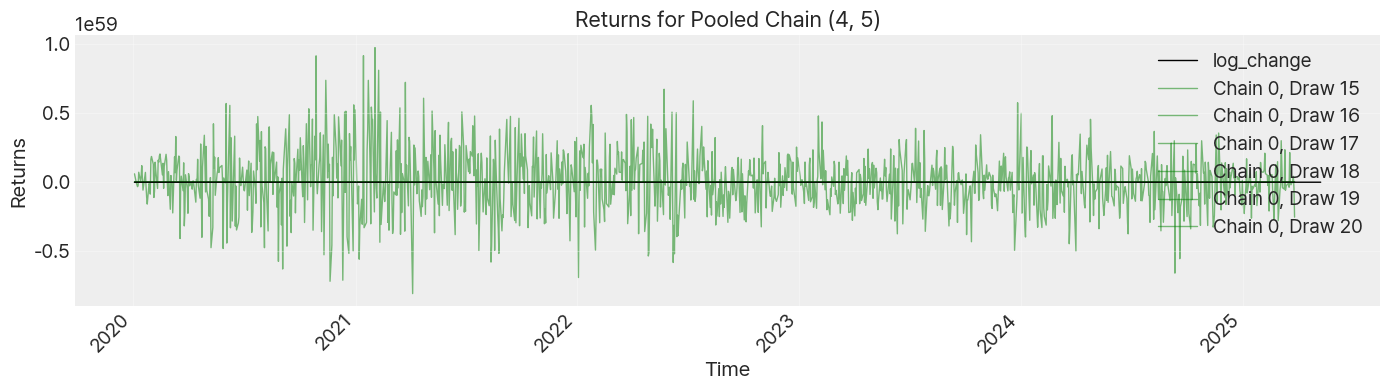

In [155]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(15, 21, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [156]:
with stochastic_vol_model:
    idata.extend(pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True}))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
# posterior["volatility"] = np.exp(posterior["volatility"])

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [step_size, log_volatility, nu, delta, y]
>BinaryGibbsMetropolis: [jump_indicator]


ValueError: Not enough samples to build a trace.

In [ ]:
from datetime import datetime
import arviz as az

# 현재 날짜와 시간
now = datetime.now()
formatted_time = now.strftime("%Y%m%d%H%M")  # 202505081200 형식

# 파일 저장
az.to_netcdf(idata, f"trace-svj-{formatted_time}.nc")

'trace-svj-202505091209.nc'

In [ ]:
posterior["volatility"]

<xarray.DataArray 'volatility' (time: 1314, pooled_chain: 12000)>
array([[0.00732997, 0.00815844, 0.00808809, ..., 0.00670943, 0.00669218,
        0.00670418],
       [0.0080346 , 0.00780685, 0.00814854, ..., 0.0072681 , 0.00701308,
        0.00748645],
       [0.00893366, 0.00819095, 0.00819518, ..., 0.0074958 , 0.00721935,
        0.00798089],
       ...,
       [0.00797293, 0.00815152, 0.00837895, ..., 0.00934157, 0.0086787 ,
        0.0090734 ],
       [0.00792407, 0.00843669, 0.00834823, ..., 0.00922678, 0.00856306,
        0.00944201],
       [0.00822364, 0.00800097, 0.00828936, ..., 0.00920897, 0.00932682,
        0.00972259]])
Coordinates:
  * time          (time) datetime64[ns] 2020-01-03 2020-01-06 ... 2025-03-26
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 0 1 2 3 4 5 ... 2995 2996 2997 2998 2999

In [ ]:
posterior

<xarray.Dataset>
Dimensions:            (time: 1314, pooled_chain: 12000,
                        jump_effect_dim_0: 1314, lambda_dim_0: 1314)
Coordinates:
  * time               (time) datetime64[ns] 2020-01-03 ... 2025-03-26
  * jump_effect_dim_0  (jump_effect_dim_0) int64 0 1 2 3 ... 1310 1311 1312 1313
  * lambda_dim_0       (lambda_dim_0) int64 0 1 2 3 4 ... 1310 1311 1312 1313
  * pooled_chain       (pooled_chain) object MultiIndex
  * chain              (pooled_chain) int64 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw               (pooled_chain) int64 0 1 2 3 4 ... 2996 2997 2998 2999
Data variables: (12/13)
    log_volatility     (time, pooled_chain) float64 -4.916 -4.809 ... -4.633
    jump_counts        (time, pooled_chain) int64 1 1 1 1 1 1 3 ... 2 2 2 2 2 2
    jump_indicator     (time, pooled_chain) int64 0 0 1 0 0 1 0 ... 0 0 1 0 0 0
    jump_size_mean     (pooled_chain) float64 -0.2123 -0.2118 ... 0.02194
    jump_size          (time, pooled_chain) float64 -0.2128 -0.2124 ... -0.01631
    step_size          (pooled_chain) float64 0.09283 0.09011 ... 0.07636
    ...                 ...
    jump_prob          (pooled_chain) float64 0.2255 0.229 ... 0.2704 0.2784
    jump_size_sd       (pooled_chain) float64 0.01307 0.01174 ... 0.05408
    nu                 (pooled_chain) float64 27.29 19.13 16.79 ... 15.19 17.69
    volatility         (time, pooled_chain) float64 0.00733 ... 0.009723
    jump_effect        (jump_effect_dim_0, pooled_chain) float64 -0.0 ... -0.0
    lambda             (lambda_dim_0, pooled_chain) float64 1.861e+04 ... 1.0...
Attributes:
    created_at:                 2025-05-09T12:08:32.409856
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1139.0158245563507
    tuning_steps:               1000

In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [ ]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda_jump,0.713,0.487,0.085,1.605,0.209,0.156,6.0,16.0,1.71
jump_size_sd,0.102,0.063,0.010,0.207,0.024,0.018,7.0,11.0,1.61
jump_counts[2021-02-25T00:00:00.000000000],0.727,1.003,0.000,3.000,0.252,0.182,17.0,29.0,1.16
jump_counts[2020-11-13T00:00:00.000000000],0.699,0.975,0.000,2.000,0.229,0.164,18.0,29.0,1.15
jump_counts[2023-02-08T00:00:00.000000000],0.698,0.970,0.000,2.000,0.233,0.167,18.0,33.0,1.15
...,...,...,...,...,...,...,...,...,...
volatility[2021-03-05T00:00:00.000000000],0.011,0.002,0.007,0.014,0.000,0.000,1804.0,2717.0,1.01
volatility[2021-03-04T00:00:00.000000000],0.011,0.002,0.007,0.015,0.000,0.000,1960.0,2986.0,1.01
volatility[2021-03-03T00:00:00.000000000],0.011,0.002,0.008,0.015,0.000,0.000,1981.0,3391.0,1.01
volatility[2021-03-02T00:00:00.000000000],0.011,0.002,0.007,0.015,0.000,0.000,2017.0,3712.0,1.01


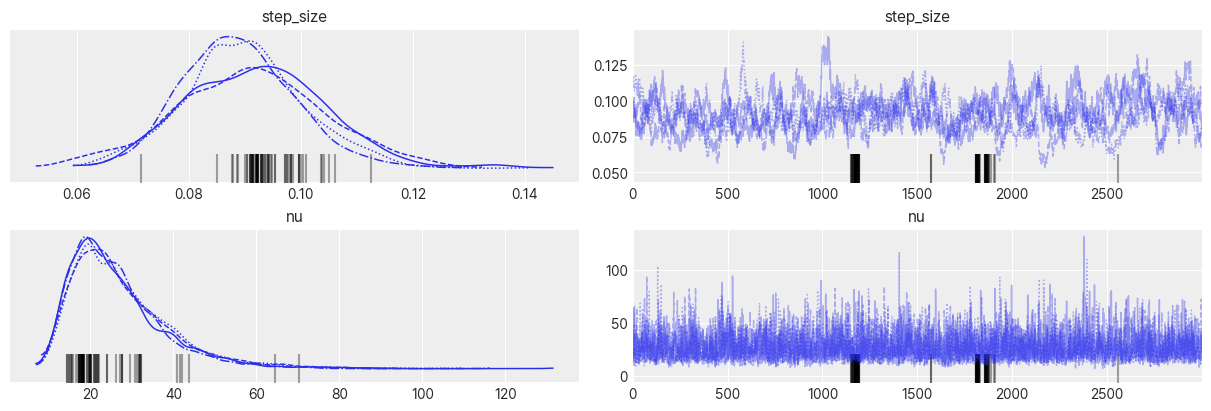

In [ ]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [ ]:
az.loo(idata)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 12000 posterior samples and 1314 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4173.54    32.15
p_loo       72.43        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     1302   99.1%
 (0.5, 0.7]   (ok)         11    0.8%
   (0.7, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%

In [ ]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)


Sampling: [returns]


In [ ]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data

In [ ]:
posterior_predictive.posterior_predictive["returns"].shape

(4, 3000, 1314)

(-0.05, 0.05)

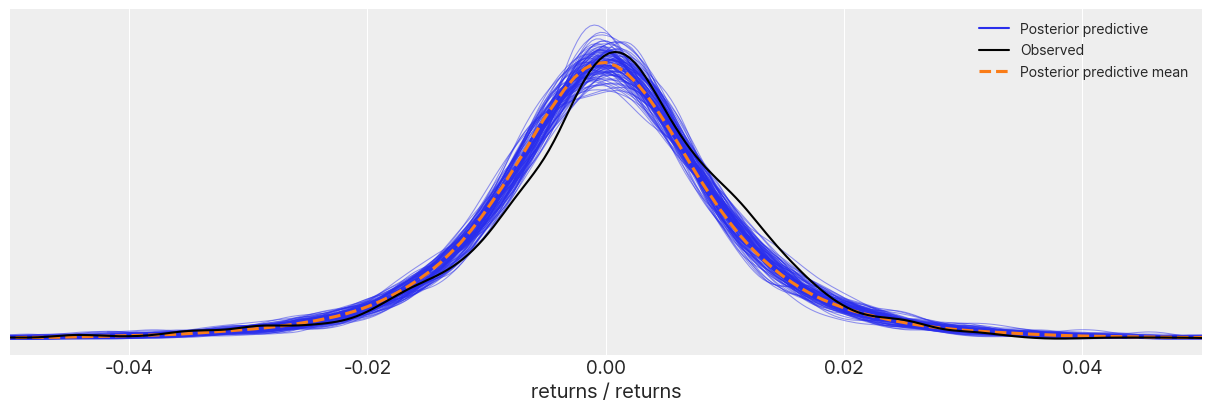

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
az.plot_ppc(posterior_predictive, num_pp_samples=100, ax=ax, kind="kde", alpha=0.5);
ax.set_xlim(-0.05, 0.05)

<Axes: title={'center': 'returns / returns'}>

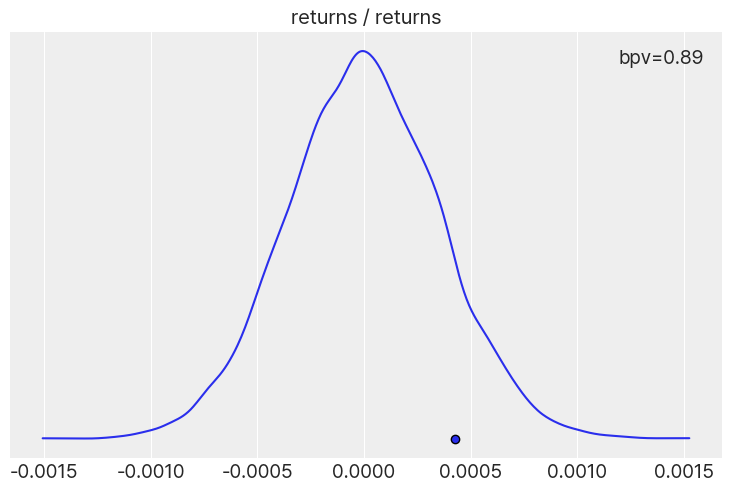

In [ ]:
az.plot_bpv(posterior_predictive, kind="t_stat", t_stat="mean")

In [ ]:
posterior

<xarray.Dataset>
Dimensions:            (time: 1314, pooled_chain: 12000,
                        jump_effect_dim_0: 1314, lambda_dim_0: 1314)
Coordinates:
  * time               (time) datetime64[ns] 2020-01-03 ... 2025-03-26
  * jump_effect_dim_0  (jump_effect_dim_0) int64 0 1 2 3 ... 1310 1311 1312 1313
  * lambda_dim_0       (lambda_dim_0) int64 0 1 2 3 4 ... 1310 1311 1312 1313
  * pooled_chain       (pooled_chain) object MultiIndex
  * chain              (pooled_chain) int64 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw               (pooled_chain) int64 0 1 2 3 4 ... 2996 2997 2998 2999
Data variables: (12/13)
    log_volatility     (time, pooled_chain) float64 -4.916 -4.809 ... -4.633
    jump_counts        (time, pooled_chain) int64 1 1 1 1 1 1 3 ... 2 2 2 2 2 2
    jump_indicator     (time, pooled_chain) int64 0 0 1 0 0 1 0 ... 0 0 1 0 0 0
    jump_size_mean     (pooled_chain) float64 -0.2123 -0.2118 ... 0.02194
    jump_size          (time, pooled_chain) float64 -0.2128 -0.2124 ... -0.01631
    step_size          (pooled_chain) float64 0.09283 0.09011 ... 0.07636
    ...                 ...
    jump_prob          (pooled_chain) float64 0.2255 0.229 ... 0.2704 0.2784
    jump_size_sd       (pooled_chain) float64 0.01307 0.01174 ... 0.05408
    nu                 (pooled_chain) float64 27.29 19.13 16.79 ... 15.19 17.69
    volatility         (time, pooled_chain) float64 0.00733 ... 0.009723
    jump_effect        (jump_effect_dim_0, pooled_chain) float64 -0.0 ... -0.0
    lambda             (lambda_dim_0, pooled_chain) float64 1.861e+04 ... 1.0...
Attributes:
    created_at:                 2025-05-09T12:08:32.409856
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              1139.0158245563507
    tuning_steps:               1000

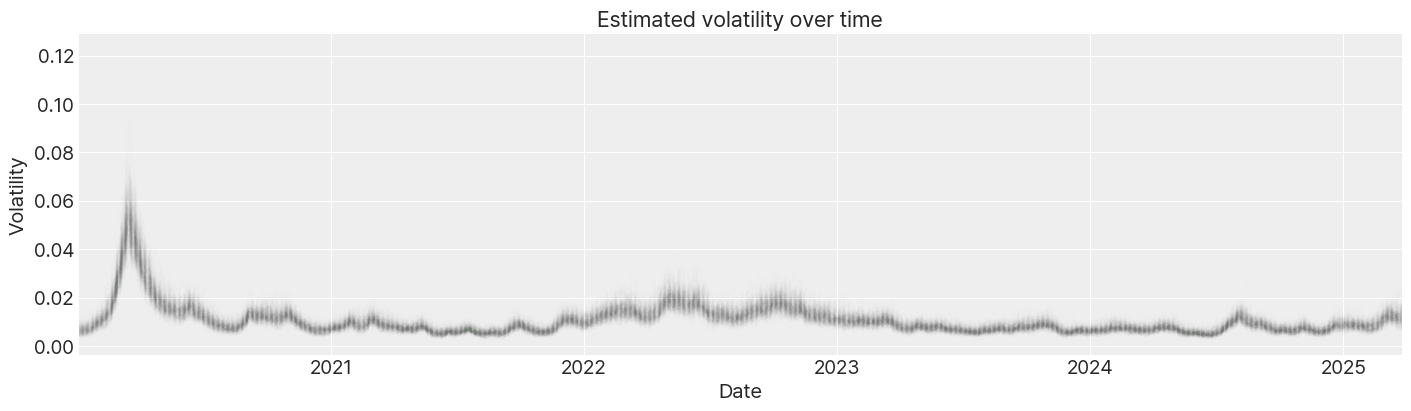

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 50))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
# ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

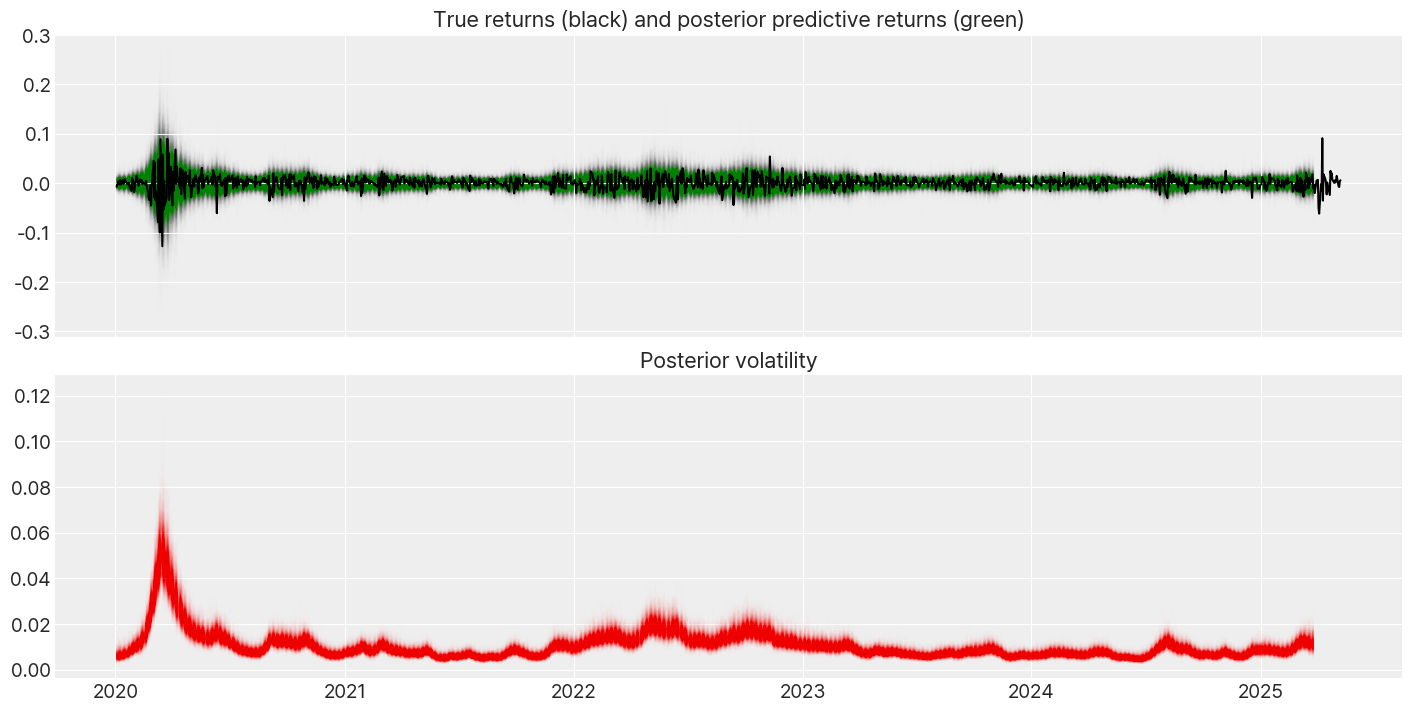

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["log_change"].plot(ax=axes[0], color="black")

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)
axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");
# plt.xlim(x_vals[-100], x_vals.max())

In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [ ]:
def create_forecast_model(data, idata, forecast_steps):
    """
    data: 원본 데이터프레임
    idata: 학습된 사후분포 (InferenceData 객체)
    forecast_steps: 예측 기간
    """
    import pymc as pm
    import numpy as np

    # 기존 모델의 마지막 시점 인덱스
    last_time = data.index[-1]
    forecast_dates = pd.date_range(start=last_time, periods=forecast_steps + 1, freq="D")[1:]

    with pm.Model(coords={"forecast_time": forecast_dates}) as forecast_model:
        # 사후분포로부터 mu와 step_size의 값을 추출
        step_size = pm.Exponential("step_size", 10)
        
        # 예측을 위한 Gaussian Random Walk
         # init_volatility를 스칼라 값으로 변환
        init_volatility_value = idata.posterior["log_volatility"].sel(time=last_time).mean().item()
        init_volatility = pm.DiracDelta.dist(init_volatility_value)

        forecast_log_volatility = pm.GaussianRandomWalk(
            "forecast_log_volatility", 
            sigma=step_size, 
            init_dist=init_volatility, 
            dims="forecast_time"
        )

        forecast_volatility = pm.Deterministic("forecast_volatility", pm.math.exp(forecast_log_volatility), dims="forecast_time")

        # 포아송 분포로 점프 횟수 결정 (λ)
        forecast_lambda_jump = pm.Exponential("forecast_lambda_jump", 1.0)
        forecast_jump_counts = pm.Poisson("forecast_jump_counts", mu=forecast_lambda_jump, dims="forecast_time")

        # 각 시점에서 점프가 발생할 확률
        forecast_jump_prob = pm.Beta("forecast_jump_prob", alpha=2, beta=10)
        forecast_jump_indicator = pm.Bernoulli("forecast_jump_indicator", p=forecast_jump_prob, dims="forecast_time")

        # 점프 크기
        forecast_jump_size_mean = pm.Normal("forecast_jump_size_mean", mu=0, sigma=0.05)
        forecast_jump_size_sd = pm.HalfNormal("forecast_jump_size_sd", sigma=0.1)
        forecast_jump_size = pm.Normal("forecast_jump_size", mu=forecast_jump_size_mean, sigma=forecast_jump_size_sd, dims="forecast_time")

        # 점프 효과
        forecast_jump_effect = pm.Deterministic("forecast_jump_effect", forecast_jump_indicator * forecast_jump_size)

        forecast_log_volatility_with_jump = forecast_log_volatility + forecast_jump_effect

        forecast_lam = pm.Deterministic("forecast_lambda", pm.math.exp(-2 * forecast_log_volatility_with_jump))
        forecast_nu = pm.Exponential("forecast_nu", 0.1)

        # 예측된 변동성에 따른 Student-T 분포 생성
        forecast_returns = pm.StudentT(
            "forecast_returns", 
            nu=forecast_nu, 
            lam=forecast_lam, 
            dims="forecast_time"
        )

    return forecast_model

forecast_model = create_forecast_model(train_data, idata=idata, forecast_steps=30)

In [ ]:
with forecast_model:
    forecast_posterior = pm.sample_posterior_predictive(
        idata,
        var_names=["forecast_returns", "forecast_log_volatility", "forecast_volatility"],
        predictions=True,
        random_seed=42
    )

Sampling: [forecast_jump_indicator, forecast_jump_prob, forecast_jump_size, forecast_jump_size_mean, forecast_jump_size_sd, forecast_log_volatility, forecast_nu, forecast_returns]


In [ ]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [ ]:
forecast_posterior

Inference data with groups:
	> predictions

(-0.15, 0.15)

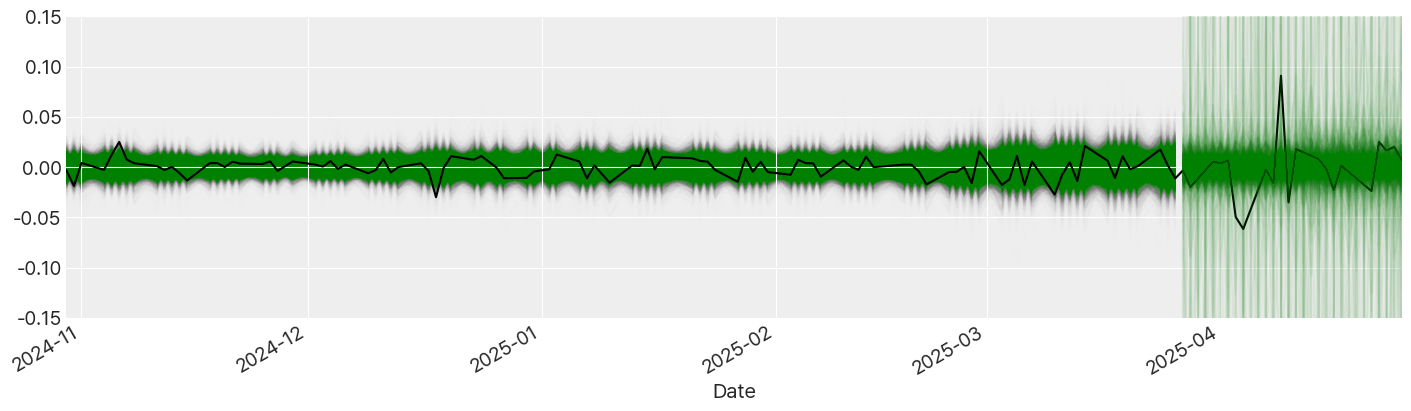

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, color="black")

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, None))
x_vals1 = y_vals.time.astype(np.datetime64)
ax.plot(x_vals1, y_vals, "g", alpha=0.002,
    zorder=-10)
 
stack = forecast_posterior.predictions["forecast_returns"].stack(pooled_chain=("chain", "draw"))
y_vals = stack.isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.forecast_time.astype(np.datetime64)

ax.plot(x_vals, y_vals, "g", alpha=0.02);

ax.set_xlim(x_vals1[-100], x_vals.max())
ax.set_ylim(-0.15, 0.15)

